In [1]:
# Standard libraries
import numpy as np
import os
import gc
import re
import time
import json
import shutil
import pickle
from tqdm import tqdm
from scipy import stats

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import _LRScheduler
from torchsummary import summary
from torchmetrics import ConfusionMatrix

# Computer vision libraries
import cv2 as cv
import torchvision
import torchvision.models as models
import torchvision.transforms as T

# Load pytorch utils from one level below
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..' )))

# GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Data analysis and visualization
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.model_selection import train_test_split

# Check matplotlib backend
default_matplotlib_backend = matplotlib.get_backend()
print('imported')
print('default_matplotlib_backend: {}'.format(default_matplotlib_backend))

imported
default_matplotlib_backend: module://matplotlib_inline.backend_inline


## Constants

In [2]:
# Important, to have the same repartition of data between different machines
np.random.seed(42)

# ===== CONFIGURATION =====
# Main configuration dictionary for paths and settings
CONFIG = {
    # Path configuration
    'paths': {
        'dataset': 'ADD PATH HERE',  # Path to the dataset
        'root': 'ADD ROOT DIRECTORY HERE',    # Root project folder
    },
    # Dataset configuration
    'dataset': {
        'split_json': 'NEW25split.json',  # JSON file defining train/valid/test split
    },
    # Model parameters
    'model': {
        'batch_size': 16,
        'day_to_use': 8,
        'images_in_a_day': 2,
        'epochs': 20,
        'img_size': (350, 350),  # Base size for images
        'resize_size': (128, 128),
        'num_channels': 3,
        'backbone': 'EfficientNetB2',
        'optimizer': 'Adam'
    },
}


# ===== DERIVED PATHS =====
# Create derived paths from the configuration
WEIGHTS_PATH = os.path.join(CONFIG['paths']['root'], 'weights')
STATS_PATH = os.path.join(CONFIG['paths']['root'], 'stats')
NPY_DATA_PATH = os.path.join(CONFIG['paths']['root'], 'npy_data')
MODEL_SAVE_PATH = os.path.join(CONFIG['paths']['root'], 'model.pth')
MODEL_SAVE_PATH_AS_STR = str(MODEL_SAVE_PATH)

# ===== DIRECTORY CREATION =====
# Create necessary directories
for path in [NPY_DATA_PATH, WEIGHTS_PATH, STATS_PATH, os.path.dirname(MODEL_SAVE_PATH)]:
    if not os.path.exists(path):
        os.makedirs(path)

# ===== DATASET SETUP =====
# Get dataset path from configuration
DATASET_PATH = CONFIG['paths']['dataset']

# Get the list of classes
class_list = os.listdir(DATASET_PATH)
class_list.sort()
print('Number of classes: {}'.format(len(class_list)))

# ===== HARDWARE SETUP =====
# Set working device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Selected device: {}'.format(device))
if device.type != 'cpu':
    print('Device name: {}'.format(torch.cuda.get_device_name(device)))

# ===== MODEL PARAMETERS =====
# Extract model parameters from configuration
BATCH_SIZE = CONFIG['model']['batch_size']
DAY_TO_USE = CONFIG['model']['day_to_use']
IMAGES_IN_A_DAY = CONFIG['model']['images_in_a_day']
SEQ_LEN = DAY_TO_USE * IMAGES_IN_A_DAY
EPOCHS = CONFIG['model']['epochs']
IMG_SIZE = CONFIG['model']['img_size']
RESIZE_SIZE = CONFIG['model']['resize_size']
NUM_CHANNELS = CONFIG['model']['num_channels']
BACKBONE = CONFIG['model']['backbone']
OPTIMIZER = CONFIG['model']['optimizer']

# Make available options accessible
train_valid_test_split_json_name = CONFIG['dataset']['split_json']

Number of classes: 25
Selected device: cuda
Device name: NVIDIA RTX A6000


## Data loading

In [3]:
image_files = []
targets = []
extracted_data_path = DATASET_PATH

# dict helps to go from class_name to class_index
class_dict = dict([(j, i) for i, j in enumerate(class_list)])

# loading all image_paths (IN A SORTED ORDER, this is really important to avoid any weird exceptions)
for class_name in class_dict.keys():
    if class_name.startswith('.'):
        continue
    repetitions_list = os.listdir(extracted_data_path + class_name)
    repetitions_list.sort()
    for repetition in repetitions_list:
        if repetition.startswith('.'):
            continue
        image_list = os.listdir(extracted_data_path + class_name + os.sep + repetition)
        image_list.sort()
        image_files.extend(
            [extracted_data_path + class_name + os.sep + repetition + os.sep + img for img in image_list]
        )
        targets.extend([class_dict[class_name]] * len(image_list))

targets = np.array(targets)

In [4]:
from copy import deepcopy

def _fix_images_paths(images_paths, targets):
    images_paths = deepcopy(images_paths)
    targets = deepcopy(targets)
    while os.path.basename(images_paths[0]).split('_')[1:4] != os.path.basename(image_files[1]).split('_')[1:4]:
        images_paths = images_paths[1:]
        targets = targets[1:]
    while os.path.basename(images_paths[-1]).split('_')[1:4] != os.path.basename(image_files[-2]).split('_')[1:4]:
        images_paths = images_paths[:-1]
        targets = targets[:-1]
    return images_paths, targets

def prepare_dataset(image_files, targets, train_valid_test_split, fix_len=10):
    images_paths, targets_cls = _fix_images_paths(image_files, targets)

    data_as_dict = {}
    for el, _trg in zip(images_paths, targets_cls):
        _cls, _rep_name = el.split(os.sep)[-3:-1]
        k = (_cls, _rep_name)
        if k not in data_as_dict:
            data_as_dict[k] = []
        data_as_dict[k].append((el, _trg))

    # Add more images to the dataset to make it divisible by fix_len
    for k in data_as_dict:
        while len(data_as_dict[k]) % fix_len != 0:
            data_as_dict[k].append(data_as_dict[k][-1])
    
    datas = {}
    for k in train_valid_test_split:
        for rep_name in train_valid_test_split[k]:
            if (k, rep_name) not in data_as_dict:
                continue
            data_type = train_valid_test_split[k][rep_name]
            if data_type not in datas:
                datas[data_type] = []
            files_in_rep = len(data_as_dict[(k, rep_name)])
            for start_idx in range(0,files_in_rep-fix_len+1,2):
                seq = data_as_dict[(k, rep_name)][start_idx:start_idx+fix_len]
                assert len(seq) == fix_len, '...'
                datas[data_type].append(seq)
    return datas

with open(os.path.join(train_valid_test_split_json_name), 'r') as f:
    train_valid_test_split = json.load(f)
datas = prepare_dataset(image_files, targets, train_valid_test_split, fix_len=max(SEQ_LEN, 10))

## Image Augmentation

Utility functions include `rotate_image` for simple rotation and `zoom_at` for zooming/rotating around specific coordinates.

The Albumentations pipeline applies aggressive augmentations when enabled: resizing, rotation up to 180°, horizontal/vertical flips (90% probability), and shift/scale/rotate transformations.

In [5]:
USE_AUGMENTATION = False

def rotate_image(image, angle):
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv.getRotationMatrix2D(image_center, angle, 1.0)
    result = cv.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv.INTER_LINEAR)
    return result

def zoom_at(img, zoom=1, angle=0, coord=None):
    cy, cx = [ i/2 for i in img.shape[:-1] ] if coord is None else coord[::-1]
    rot_mat = cv.getRotationMatrix2D((cx,cy), angle, zoom)
    result = cv.warpAffine(img, rot_mat, img.shape[1::-1], flags=cv.INTER_LINEAR)
    return result

import albumentations as A

class ClassificationPlantSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, data, use_augmentation=False):
        self.use_augmentation = use_augmentation
        self.data = data

        if self.use_augmentation:
            self.transform = A.Compose([
                A.Resize(RESIZE_SIZE[0], RESIZE_SIZE[1]),
                A.Rotate(limit=180, p=0.7),
                A.Flip(p=0.9),
                A.ShiftScaleRotate(shift_limit=0.2, scale_limit=(0.2, 0.5)),
            ])
        else:
            self.transform = A.Compose([
                A.Resize(RESIZE_SIZE[0], RESIZE_SIZE[1]),
            ])

    def __getitem__(self, index):
        seq, classes = list(zip(*self.data[index]))
        assert len(set(classes)) == 1, 'wrong seq clses'
        seq_cls = classes[0]

        images = []
        for im_path in seq:
            img = cv.imread(im_path)
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            img = cv.resize(img, IMG_SIZE)
            img = self.transform(image=img)['image']
            img = img.astype(np.float32) / 255.
            img = torch.from_numpy(img.transpose((2, 0, 1)))
            images.append(img)

        images = torch.stack(images)
        images = torch.permute(images, (1, 0, 2, 3))
        return images, seq_cls

    def __len__(self):
        return len(self.data)

# loading data
train_dataset = ClassificationPlantSequenceDataset(datas['train'], use_augmentation=USE_AUGMENTATION)
val_dataset = ClassificationPlantSequenceDataset(datas['valid'])
test_dataset = ClassificationPlantSequenceDataset(datas['test'])

# # combine val and test
val_dataset = torch.utils.data.ConcatDataset([val_dataset, test_dataset])
test_dataset = val_dataset

# data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=True, drop_last=False)

print('Data loaders created')

Data loaders created


### Data sample 

Run this to see a sample of the data

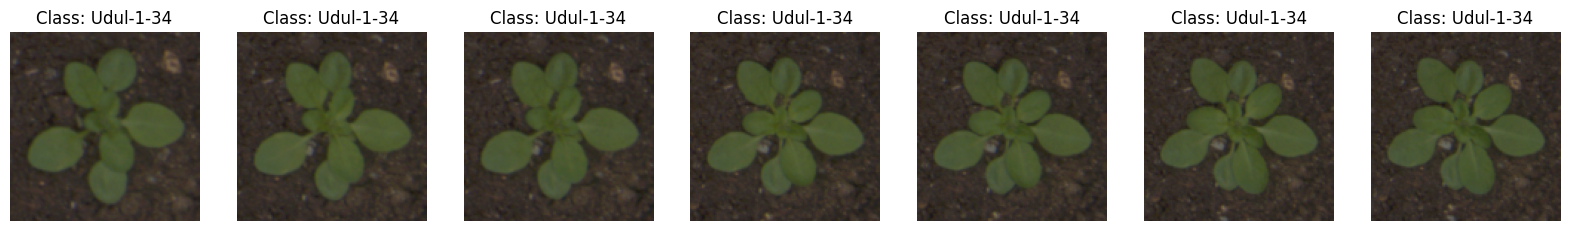

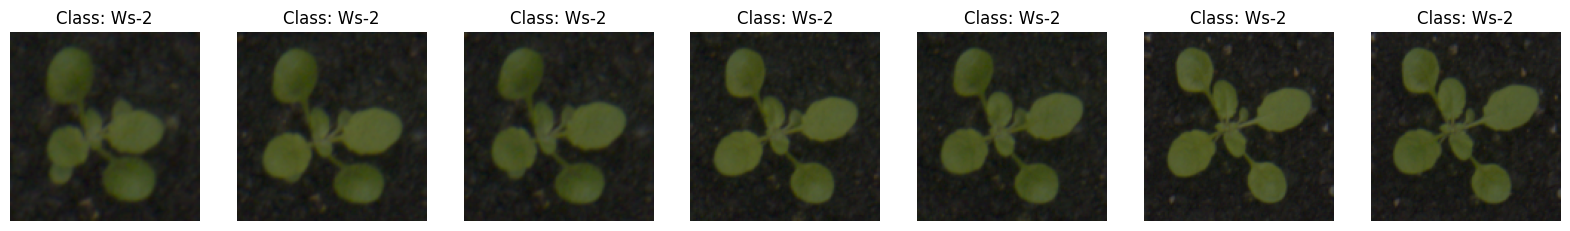

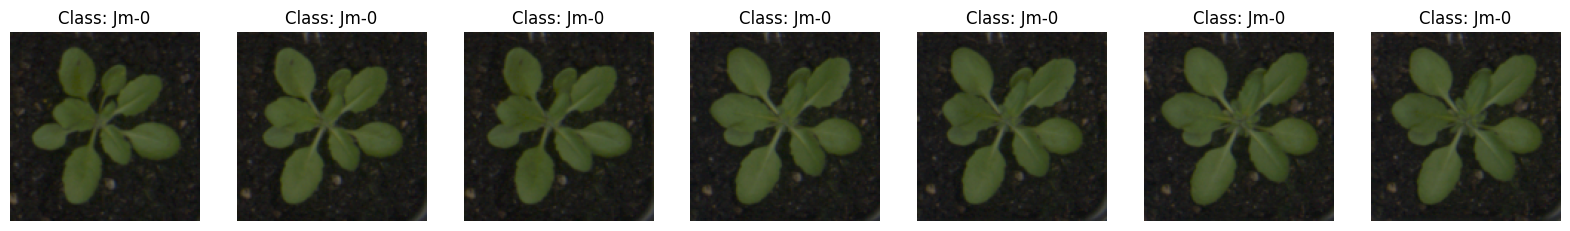

In [22]:
dataset = ClassificationPlantSequenceDataset(datas['train'], use_augmentation=USE_AUGMENTATION)
idxs_in_batch = [0,1,2]
sample_size = 7
for idx_in_batch in idxs_in_batch:
    img_idx = np.random.randint(0, len(dataset), size=sample_size)
    sample = [dataset[i] for i in img_idx]
    imgs = sample[idx_in_batch][0].cpu()
    plt.figure(figsize=(20, 10))
    for i in range(sample_size):
        img = imgs[:,i,:,:].permute(1, 2, 0)
        plt.subplot(1, sample_size, i + 1)
        plt.imshow((img * 255).type(torch.uint8))
        plt.title('Class: {}'.format(class_list[sample[idx_in_batch][1]]))
        plt.axis('off')
    plt.show()

### LR Scheduler and utility functions

1. `PolyScheduler` is a custom learning rate scheduler that starts with a warmup phase (gradually increasing from 0.0001 to base_lr), then applies polynomial decay with power=2 to reduce the learning rate as training progresses.
2. `plot_model_stats` creates side-by-side plots showing training/validation loss and accuracy curves over epochs, with the final validation metrics displayed in the titles.
3. `load_model_weights` loads a pre-trained PyTorch model from a .pth file based on the specified backbone architecture and optimizer configuration.
4. `load_model_stats` loads previously saved training statistics (loss/accuracy histories) from a pickle file for analysis or visualization.

In [7]:
class PolyScheduler(_LRScheduler):
    def __init__(self, optimizer, base_lr, max_steps, warmup_steps, last_epoch=-1):
        self.base_lr = base_lr
        self.warmup_lr_init = 0.0001
        self.max_steps: int = max_steps
        self.warmup_steps: int = warmup_steps
        self.power = 2
        super(PolyScheduler, self).__init__(optimizer, -1, False)
        self.last_epoch = last_epoch

    def get_warmup_lr(self):
        alpha = float(self.last_epoch) / float(self.warmup_steps)
        return [self.base_lr * alpha for _ in self.optimizer.param_groups]

    def get_lr(self):
        if self.last_epoch == -1:
            return [self.warmup_lr_init for _ in self.optimizer.param_groups]
        if self.last_epoch < self.warmup_steps:
            return self.get_warmup_lr()
        else:
            alpha = pow(
                1
                - float(self.last_epoch - self.warmup_steps)
                / float(self.max_steps - self.warmup_steps),
                self.power,
            )
            return [self.base_lr * alpha for _ in self.optimizer.param_groups]

def plot_model_stats(model_name, train_loss, train_acc, test_loss, test_acc):
    fig = plt.figure(figsize=(16, 5))
    ax1 = plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(train_loss)), train_loss, label = 'Train loss')
    plt.plot(np.arange(len(test_loss)), test_loss, label = 'Val loss')
    plt.title('Model: {} - Validation loss: {:.4f}'.format(model_name, test_loss[-1]))
    ax1.set_ylabel("Loss")
    ax1.set_xlabel("Epochs")
    ax1.legend(loc='upper right')
    ax2 = plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(train_acc)), np.array(train_acc) * 100, color='green', label = 'Train accuracy')
    plt.plot(np.arange(len(test_acc)), np.array(test_acc) * 100, color='red', label = 'Val accuracy')
    plt.title('Model: {} - Validation accuracy: {:.2f} %'.format(model_name, test_acc[-1] * 100))
    ax2.set_ylabel("Accuracy")
    ax2.set_xlabel("Epochs")
    ax2.legend(loc='lower right')
    plt.show()

def load_model_weights(BACKBONE=BACKBONE, OPTIMIZER=OPTIMIZER):
    # this function loads the whole model with weights
    pth = os.path.join(weights_path, 'backbone_{}_{}.pth'.format(BACKBONE, OPTIMIZER))
    assert os.path.exists(pth), 'Configuration not found'
    model = torch.load(pth).to(device)
    print('Backbone weights loaded: {}'.format(BACKBONE))
    return model

def load_model_stats(BACKBONE=BACKBONE, OPTIMIZER=OPTIMIZER):
    # this function loads training stats (train/val loss and acc)
    stats_file = os.path.join(stats_path, 'stats_{}_{}.pkl'.format(BACKBONE, OPTIMIZER))
    assert os.path.exists(stats_file), 'Configuration not found'
    with open(stats_file, 'rb') as stats:
        stats = pickle.load(stats)
    print('Train/Validation stats loaded for the model: {}'.format(BACKBONE))
    return stats

## Training and evaluation functions

`_handlezero_division_np(a, b)` performs safe element-wise division of arrays `a / b`, assigning 0 where `b == 0`. 

The `mathews_correlation_coefficient_np(tp, fp, fn, tn)` function computes the Matthews Correlation Coefficient (MCC), a balanced binary classification metric even under class imbalance. It uses the standard MCC formula and includes an `eps` term to prevent divide-by-zero errors.

MCC ranges from -1 (total disagreement) to +1 (perfect prediction), with 0 indicating random performance.


In [8]:
def _handlezero_division_np(a,b):
    # initialize output tensor with desired value
    c = np.zeros_like(a)
    mask = (b != 0)
    # finally perform division
    c[mask] = a[mask] / b[mask]
    return c

def mathews_correlation_coefficient_np(tp, fp, fn, tn):
    tp = tp.sum().astype(np.float64)
    tn = tn.sum().astype(np.float64)
    fp = fp.sum().astype(np.float64)
    fn = fn.sum().astype(np.float64)
    _numerator = (tp*tn - fp*fn)
    _denomerator = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    x = _numerator / (_denomerator + 1e-11)
    return x

## Define callbacks

Includes learning rate scheduler and validation callbacks.

In [9]:
import pytorch_utils.callbacks as pt_callbacks

# === Explicit Boolean Flags ===
USE_LR_SCHEDULER = True
USE_EARLY_STOPPING = True

def get_callbacks(
        optimiser,
        result,
        model,
        defined_callbacks=None,
        continue_training=False,
        other_stats=None
):
    model_save_path = MODEL_SAVE_PATH_AS_STR # Ensure this path exists or pass it as an argument

    if defined_callbacks is None:
        defined_callbacks = {
            'val': pt_callbacks.Callbacks(
                optimizer=optimiser,
                model_save_path=model_save_path + 'model.pth',
                training_stats_path=model_save_path + 'training_stats_val',
                continue_training=continue_training
            ),
            'train': pt_callbacks.Callbacks(
                optimizer=optimiser,
                training_stats_path=model_save_path + 'training_stats_train',
                continue_training=continue_training
            )
        }

    # === Apply Callbacks Conditionally ===
    if USE_LR_SCHEDULER:
        defined_callbacks['val'].reduce_lr_on_plateau(
            monitor_value=result["val_acc"],
            mode='max',
            factor=0.5,
            patience=5,
            indicator_text="Val LR scheduler: "
        )

    defined_callbacks['val'].model_checkpoint(
        model=model,
        monitor_value=result["val_acc"],
        mode='max',
        indicator_text="Val checkpoint: "
    )

    stop_flag = False
    if USE_EARLY_STOPPING:
        stop_flag = defined_callbacks['val'].early_stopping(
            monitor_value=result["val_acc"],
            mode='max',
            patience=25,
            indicator_text="Early stopping: "
        )

    defined_callbacks['val'].clear_memory()
    print("_________")

    return defined_callbacks, stop_flag


## Define training loop and evaluation

In [10]:
import pytorch_utils.training_utils as pt_train

def train_loop(
        model_name,
        model,
        optimizer,
        epochs,
        train_loader,
        val_loader,
        model_save_folder=MODEL_SAVE_PATH,
        initial_lr=0.001,
        weight_decay=None,
        running_hyperopt=False,
        verbose=False,
        continue_training=False,
        USE_TWO_GPUS=False
):
    def get_result_list(history, metric):
        return [history[i][metric] for i in range(len(history))]

    import os
    # prep the model save path
    shutil.rmtree(model_save_folder, ignore_errors=True)
    os.makedirs(model_save_folder, exist_ok=True)

    # Train the model using torch
    
        
    history = pt_train.fit_seq(
        model_name=model_name,
        epochs=epochs,
        lr=initial_lr,
        weight_decay=weight_decay,
        model=model,
        continue_training=continue_training,
        callbacks_function=get_callbacks,
        train_loader=train_loader,
        val_loader=val_loader,
        opt_func=optimizer,
        USE_TWO_GPUS=USE_TWO_GPUS,
        MODELS_DIR=model_save_folder,
        SEQ_LEN=SEQ_LEN
    )

    train_loss_history = get_result_list(history, "train_loss")
    train_acc_history = get_result_list(history, "train_acc")
    val_loss_history = get_result_list(history, "val_loss")
    val_acc_history = get_result_list(history, "val_acc")
    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history


def evaluate_model(model, test_loader, verbose=True, eps=1e-10):
    if verbose:
        print('--------------------------------------------')
        print('Test metrics (on test set)')

    model.eval()

    confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=len(class_list))
    eval_preds = list()
    eval_targs = list()

    # computing predictions and confusion matrix
    for i, (images, targets) in enumerate(tqdm(test_loader, position=0, leave=True)):
        images, targets = images.to(device, dtype=torch.float), torch.Tensor(targets).to(device)
        outputs = torch.nn.functional.log_softmax(model(images), dim=1)
        preds = torch.argsort(outputs, dim=1, descending=True)[:, :3]
        eval_preds.extend(preds[:, 0].cpu().numpy())
        eval_targs.extend(targets.cpu().numpy())

    # computing main metrics (acc, precisio, recall and f1 score)
    matrix = confusion_matrix(torch.tensor(eval_preds), torch.tensor(eval_targs))
    accuracy = matrix.trace() / (matrix.sum()+eps)
    # loss = F.cross_entropy(torch.tensor(eval_preds), torch.tensor(eval_targs))
    precision = np.array([matrix[i, i] / (matrix.sum(axis=0)[i]+eps) for i in range(len(class_list))])
    recall = np.array([matrix[i, i] / (matrix.sum(axis=1)[i]+eps) for i in range(len(class_list))])
    f1_score = 2 * precision * recall / (precision + recall+eps)

    # computing false positive rate, false negative rate, false discovery rate, false omission rate
    fp_rate = np.zeros(len(class_list))
    for idx in range(len(class_list)):
        tn = matrix.trace() - matrix[idx, idx]
        fp = np.sum([matrix[j, idx] for j in range(len(class_list)) if j != idx])
        fp_rate[idx] = fp / (fp + tn+eps)

    fn_rate = 1 - recall
    fd_rate = 1 - precision
    specificity = 1 - fp_rate

    fo_rate = np.zeros(len(class_list))
    for idx in range(len(class_list)):
        n = np.sum(np.array(eval_targs) != idx)
        fn = np.sum([matrix.sum(axis=0)[j] - matrix[j, j] for j in range(len(class_list)) if j != idx])
        fo_rate[idx] = fn / (n+eps)

    missclassification_rate = 1 - accuracy
    npv = 1 - fo_rate

    mcc_per_class = []
    for idx in range(len(class_list)):
        tp = matrix[idx, idx].cpu().numpy()
        tn = (matrix.trace() - matrix[idx, idx]).cpu().numpy()
        fp = np.sum([matrix[j, idx] for j in range(len(class_list)) if j != idx])
        fn = np.sum([matrix.sum(axis=0)[j] - matrix[j, j] for j in range(len(class_list)) if j != idx])
        _mcc = mathews_correlation_coefficient_np(tp, fp, fn, tn)
        mcc_per_class.append(_mcc)

    if verbose:
        print('--------------------------------------------')
        print('Accuracy: {:.3f}%'.format(accuracy * 100))
        # print('Loss: {:.3f}'.format(loss))
        print('Average precision: {:.3f}'.format(precision.mean()))
        print('Average recall: {:.3f}'.format(recall.mean()))
        print('Average F1 score: {:.3f}'.format(f1_score.mean()))
        print('Average specificity: {:.3f}'.format(specificity.mean()))
        print('Average false positive rate: {:3f}'.format(fp_rate.mean()))
        print('Average false negative rate: {:3f}'.format(fn_rate.mean()))
        print('Average false discovery rate: {:.3f}'.format(fd_rate.mean()))
        print('Average false omission rate: {:.3f}'.format(fo_rate.mean()))
        print('Missclassification rate: {:.2f}%'.format(missclassification_rate * 100))
        print('Mathews Correlation Coefficient: {:.2f}'.format(np.mean(mcc_per_class)))
        print('--------------------------------------------')
        print('Results by class :')
        print('--------------------------------------------')
        print('{:<15}{:<12}{:<12}{:<12}{:<12}{:<12}{:<12}{:<12}{:<12}{:<12}{:<12}'.format('', 'Precision', 'Recall', 'F1 score', 'Specificity', 'FPR', 'FNR', 'FDR', 'FOR', 'NPV', 'MCC'))
        for idx, class_name in enumerate(class_list):
            print('{:<15}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.3f}{:<12.3f}{:<12.3f}{:<12.3f}{:<12.3f}{:<12.3f}{:<12.3f}'.format(
                class_name, precision[idx], recall[idx], f1_score[idx], specificity[idx], fp_rate[idx], fn_rate[idx], fd_rate[idx], fo_rate[idx], npv[idx], mcc_per_class[idx]
            ))
        print('--------------------------------------------')
        print()

        # ploting confusion matrix
        matrix_df = pd.DataFrame(matrix.numpy(), index=class_list, columns=class_list)
        plt.figure(figsize=(12, 8))
        sn.heatmap(matrix_df, annot=True, fmt='d', cmap='Blues')

    return accuracy, precision, recall, f1_score, matrix_df

## Base Model Definition

Contains definitions related to the base model as well as the Vision Transformer

In [11]:
# For use with CustomModelBase
def accuracy(
        outputs: torch.Tensor,
        labels: torch.Tensor
):
    """
    Custom accuracy function to override the default one in pt_train
    """

    preds = torch.argmax(outputs, dim=1)

    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class CustomModelBase(pt_train.CustomModelBase):
    """
    ModelBase override for training and validation steps
    """

    def __init__(self, class_weights=None):
        super(CustomModelBase, self).__init__()
        self.class_weights = class_weights
        self.accuracy_function = accuracy

    def training_step(self, batch, forward_func: torch.nn=None, USE_TWO_GPUS=False):
        images, labels = batch
        labels = labels.long()
        if USE_TWO_GPUS:
            out = forward_func(images)
        else:
            out = self(images)  # Generate predictions
        loss = F.cross_entropy(out, labels, weight=self.class_weights)  # Calculate loss with class weights
        acc = accuracy(out, labels)  # Calculate accuracy
        return loss, acc

    def validation_step(self, batch, forward_func: torch.nn=None, USE_TWO_GPUS=False):
        images, labels = batch
        if USE_TWO_GPUS:
            out = forward_func(images)
        else:
            out = self(images)  # Generate predictions
        labels = labels.long()

        loss = F.cross_entropy(out, labels, weight=self.class_weights)  # Calculate loss with class weights
        acc = accuracy(out, labels)  # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

In [20]:
## Implementation of Video Vision Transfoemer

import torch
from torch import nn, einsum
import torch.nn.functional as F

from einops import rearrange, repeat
from einops.layers.torch import Rearrange


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.0):
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head**-0.5

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        self.to_out = (
            nn.Sequential(nn.Linear(inner_dim, dim), nn.Dropout(dropout))
            if project_out
            else nn.Identity()
        )

    def forward(self, x):
        b, n, _, h = *x.shape, self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, "b n (h d) -> b h n d", h=h), qkv)

        dots = einsum("b h i d, b h j d -> b h i j", q, k) * self.scale

        attn = dots.softmax(dim=-1)

        out = einsum("b h i j, b h j d -> b h i d", attn, v)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.to_out(out)
        return out


class ReAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.0):
        super().__init__()
        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head**-0.5

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        self.reattn_weights = nn.Parameter(torch.randn(heads, heads))

        self.reattn_norm = nn.Sequential(
            Rearrange("b h i j -> b i j h"),
            nn.LayerNorm(heads),
            Rearrange("b i j h -> b h i j"),
        )

        self.to_out = nn.Sequential(nn.Linear(inner_dim, dim), nn.Dropout(dropout))

    def forward(self, x):
        b, n, _, h = *x.shape, self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, "b n (h d) -> b h n d", h=h), qkv)

        # attention

        dots = einsum("b h i d, b h j d -> b h i j", q, k) * self.scale
        attn = dots.softmax(dim=-1)

        # re-attention

        attn = einsum("b h i j, h g -> b g i j", attn, self.reattn_weights)
        attn = self.reattn_norm(attn)

        # aggregate and out

        out = einsum("b h i j, b h j d -> b h i d", attn, v)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.to_out(out)
        return out


class LeFF(nn.Module):

    def __init__(self, dim=192, scale=4, depth_kernel=3):
        super().__init__()

        scale_dim = dim * scale
        self.up_proj = nn.Sequential(
            nn.Linear(dim, scale_dim),
            Rearrange("b n c -> b c n"),
            nn.BatchNorm1d(scale_dim),
            nn.GELU(),
            Rearrange("b c (h w) -> b c h w", h=14, w=14),
        )

        self.depth_conv = nn.Sequential(
            nn.Conv2d(
                scale_dim,
                scale_dim,
                kernel_size=depth_kernel,
                padding=1,
                groups=scale_dim,
                bias=False,
            ),
            nn.BatchNorm2d(scale_dim),
            nn.GELU(),
            Rearrange("b c h w -> b (h w) c", h=14, w=14),
        )

        self.down_proj = nn.Sequential(
            nn.Linear(scale_dim, dim),
            Rearrange("b n c -> b c n"),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            Rearrange("b c n -> b n c"),
        )

    def forward(self, x):
        x = self.up_proj(x)
        x = self.depth_conv(x)
        x = self.down_proj(x)
        return x


class LCAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.0):
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head**-0.5

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        self.to_out = (
            nn.Sequential(nn.Linear(inner_dim, dim), nn.Dropout(dropout))
            if project_out
            else nn.Identity()
        )

    def forward(self, x):
        b, n, _, h = *x.shape, self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, "b n (h d) -> b h n d", h=h), qkv)
        q = q[:, :, -1, :].unsqueeze(2)  # Only Lth element use as query

        dots = einsum("b h i d, b h j d -> b h i j", q, k) * self.scale

        attn = dots.softmax(dim=-1)

        out = einsum("b h i j, b h j d -> b h i d", attn, v)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.to_out(out)
        return out

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        self.norm = nn.LayerNorm(dim)
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout = dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)


class ViViT(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, num_frames, dim = 192, depth = 4, heads = 3, pool = 'cls', in_channels = 3, dim_head = 64, dropout = 0.,
                 emb_dropout = 0., scale_dim = 4, ):
        super().__init__()
        
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'


        assert image_size % patch_size == 0, 'Image dimensions must be divisible by the patch size.'
        num_patches = (image_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b t c (h p1) (w p2) -> b t (h w) (p1 p2 c)', p1 = patch_size, p2 = patch_size),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_frames, num_patches + 1, dim))
        self.space_token = nn.Parameter(torch.randn(1, 1, dim))
        self.space_transformer = Transformer(dim, depth, heads, dim_head, dim*scale_dim, dropout)

        self.temporal_token = nn.Parameter(torch.randn(1, 1, dim))
        self.temporal_transformer = Transformer(dim, depth, heads, dim_head, dim*scale_dim, dropout)

        self.dropout = nn.Dropout(emb_dropout)
        self.pool = pool

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        x = self.to_patch_embedding(x)
        b, t, n, _ = x.shape

        cls_space_tokens = repeat(self.space_token, '() n d -> b t n d', b = b, t=t)
        x = torch.cat((cls_space_tokens, x), dim=2)
        x += self.pos_embedding[:, :, :(n + 1)]
        x = self.dropout(x)

        x = rearrange(x, 'b t n d -> (b t) n d')
        x = self.space_transformer(x)
        x = rearrange(x[:, 0], '(b t) ... -> b t ...', b=b)

        cls_temporal_tokens = repeat(self.temporal_token, '() n d -> b n d', b=b)
        x = torch.cat((cls_temporal_tokens, x), dim=1)

        x = self.temporal_transformer(x)
        

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        return self.mlp_head(x)

## Definition of the Sequence Models

In [13]:
NUM_CLASSES = len(class_list)
HIDDEN_SIZE = 256
DROPOUT = 0.0

class R3D_18(CustomModelBase):
    def __init__(self, num_classes):
        super(R3D_18, self).__init__()
        self.model = models.video.r3d_18(weights=models.video.R3D_18_Weights.DEFAULT)
        self.linear = nn.Linear(self.model.fc.out_features, num_classes, bias=True)

    def forward(self, x):
        return self.model(x)

class MC3_18(CustomModelBase):
    def __init__(self, num_classes):
        super(MC3_18, self).__init__()
        self.model = models.video.mc3_18(weights=models.video.MC3_18_Weights.DEFAULT)
        self.linear = nn.Linear(self.model.fc.out_features, num_classes, bias=True)

    def forward(self, x):
        return self.model(x)

class r2plus1d_18(CustomModelBase):
    def __init__(self, num_classes):
        super(r2plus1d_18, self).__init__()
        self.model = models.video.r2plus1d_18(weights=models.video.R2Plus1D_18_Weights.DEFAULT)
        self.linear = nn.Linear(self.model.fc.out_features, num_classes, bias=True)

    def forward(self, x):
        return self.model(x)

class EfficientNetB1(CustomModelBase):
    def __init__(self, num_classes=NUM_CLASSES):
        super(EfficientNetB1, self).__init__()
        self.model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)
        self.model.classifier = nn.Identity()  # Remove last layer. Final layer in not useful when using this model as feature extractor
        self.out_features = models.efficientnet_b1().classifier[-1].in_features

    def forward(self, x):
        return self.model(x)

class Eff_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=HIDDEN_SIZE, num_layers=2):
        super(Eff_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = EfficientNetB1()

        self.lstm = nn.LSTM(self.model.out_features, self.hidden_size, self.num_layers, batch_first=True, dropout=DROPOUT)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        device = x.device
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(Eff_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(Eff_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(Eff_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.gru = nn.LSTM(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff2_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(Eff2_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff2_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(Eff2_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, dropout=0.5)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff2_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(Eff2_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class Eff2_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(Eff2_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class MNV3S_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(MNV3S_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class MNV3S_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(MNV3S_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class MNV3S_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(MNV3S_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class MNV3S_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(MNV3S_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.classifier[-1].out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R18_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R18_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R18_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R18_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R18_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R18_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R18_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R18_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R34_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R34_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R34_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R34_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R34_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R34_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R34_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R34_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R50_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R50_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R50_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R50_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R50_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R50_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R50_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R50_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R101_LSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R101_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R101_GRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2):
        super(R101_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True)
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R101_BiLSTM(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R101_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        self.lstm = nn.LSTM(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()
        c0 = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device).requires_grad_()

        out, (hn, cn) = self.lstm(embeddings, (h0.detach(), c0.detach()))
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out

class R101_BiGRU(CustomModelBase):
    def __init__(self, num_classes, hidden_size=200, num_layers=2, bidirectional=True):
        super(R101_BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        self.gru = nn.GRU(self.model.fc.out_features, self.hidden_size, self.num_layers, batch_first=True, bidirectional=bidirectional)
        self.num_directions = 2 if bidirectional else 1
        self.linear1 = nn.Linear(self.hidden_size * SEQ_LEN * self.num_directions, num_classes*2, bias=True)
        self.linear2 = nn.Linear(num_classes*2, num_classes, bias=True)

    def forward(self, x):
        embeddings = []
        for idx in range(SEQ_LEN):
            emb = self.model(x[:,:,idx])
            embeddings.append(emb[:,None])
        embeddings = torch.concat(embeddings, 1)

        h = torch.zeros(self.num_layers*self.num_directions, x.size(0), self.hidden_size).to(device)
        out, h = self.gru(embeddings, h)
        out = out.reshape(out.shape[0], -1)
        out = self.linear1(out)
        out = self.linear2(out)
        return out


In [14]:
def get_model_by_name(name):
    model_directory = {
        "R3D_18": R3D_18,
        "MC3_18": MC3_18,
        "r2plus1d_18": r2plus1d_18,
        "Eff_LSTM": Eff_LSTM,
        "Eff_GRU": Eff_GRU,
        "Eff_BiGRU": Eff_BiGRU,
        "Eff_BiLSTM": Eff_BiLSTM,
        "Eff2_LSTM": Eff2_LSTM,
        "Eff2_GRU": Eff2_GRU,
        "Eff2_BiLSTM": Eff2_BiLSTM,
        "Eff2_BiGRU": Eff2_BiGRU,
        "MNV3S_LSTM": MNV3S_LSTM,
        "MNV3S_GRU": MNV3S_GRU,
        "MNV3S_BiLSTM": MNV3S_BiLSTM,
        "MNV3S_BiGRU": MNV3S_BiGRU,
        "R18_LSTM": R18_LSTM,
        "R18_GRU": R18_GRU,
        "R18_BiLSTM": R18_BiLSTM,
        "R18_BiGRU": R18_BiGRU,
        "R34_LSTM": R34_LSTM,
        "R34_GRU": R34_GRU,
        "R34_BiLSTM": R34_BiLSTM,
        "R34_BiGRU": R34_BiGRU,
        "R50_LSTM": R50_LSTM,
        "R50_GRU": R50_GRU,
        "R50_BiLSTM": R50_BiLSTM,
        "R50_BiGRU": R50_BiGRU,
        "R101_LSTM": R101_LSTM,
        "R101_GRU": R101_GRU,
        "R101_BiLSTM": R101_BiLSTM,
        "R101_BiGRU": R101_BiGRU,
    }
    return model_directory[name]


In [ ]:
from datetime import datetime
from hyperopt import hp, STATUS_OK, fmin, tpe, space_eval, Trials
from hyperopt.pyll import scope

def train_model(kwargs):
    epochs = kwargs.get("epochs", EPOCHS)

    # get model by name
    model_name = kwargs.get("model")
    model_cls = get_model_by_name(model_name)
    model = model_cls(num_classes=len(class_list)).to('cuda:0')
    USE_TWO_GPUS = kwargs.get("USE_TWO_GPUS")

    optimizer_cls = torch.optim.Adam
    optim_args = kwargs.get('optim')
    if USE_TWO_GPUS:
        model = torch.nn.DataParallel(model)
   

    model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_loop(
        model_name,
        model,
        optimizer_cls,
        epochs,
        train_loader,
        val_loader,
        initial_lr=optim_args["params"]["lr"],
        weight_decay=optim_args["params"]["weight_decay"],
        verbose=True,
        running_hyperopt=False,
        continue_training=False,
        USE_TWO_GPUS=USE_TWO_GPUS
    )

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

def train_model_hyperopt(kwargs):

    model, train_loss_history, train_acc_history, val_loss_history, val_acc_history  = train_model(kwargs)

    return {"loss": np.mean(val_loss_history), "status": STATUS_OK}

def unpack_values(trial):
    vals = trial["misc"]["vals"]
    # unpack the one-element lists to values
    # and skip over the 0-element lists
    rval = {}
    for k, v in list(vals.items()):
        if v:
            rval[k] = v[0]
    return rval

def export_hyperopt_log(trials):
    result_list = []
    for trial in trials.trials:
        trial_result = space_eval(search_space, unpack_values(trial))
        trial_result["val_loss"] = trial['result']['loss']
        result_list.append(trial_result)

    df_result = pd.DataFrame(result_list)
    df_result = pd.concat([df_result.drop("optim", axis=1), pd.json_normalize(df_result.optim)], axis=1)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = "../data/log"
    output_path = os.path.join(output_dir, f"hyperopt_result_{ts}.csv")

    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    df_result.to_csv(output_path, index=False)
    print(f"Exported hyperopt log to {output_path}")
    return df_result


search_space = {
    "epochs": scope.int(hp.choice("epochs", [7, 10, 13, 15, 17, 20, 22, 25, 27, 30, 33, 35])),
    "model":  hp.choice("model_name", [
         "R3D_18",
         "MC3_18",
         "r2plus1d_18",
        "Eff_LSTM",
        "Eff_GRU",
        "Eff_BiGRU",
        "Eff_BiLSTM",
        "Eff2_LSTM",
        "Eff2_GRU",
        "Eff2_BiLSTM",
        "Eff2_BiGRU",
        "MNV3S_LSTM",
        "MNV3S_GRU",
        "MNV3S_BiLSTM",
        "MNV3S_BiGRU",
        "R18_LSTM",
        "R18_GRU",
        "R18_BiLSTM",
        "R18_BiGRU",
        "R34_LSTM",
        "R34_GRU",
        "R34_BiLSTM",
        "R34_BiGRU",
        "R50_LSTM",
        "R50_GRU",
        "R50_BiLSTM",
        "R50_BiGRU",
        "R101_LSTM",
        "R101_GRU",
        "R101_BiLSTM",
        "R101_BiGRU",
        "ViViT_small",
        "ViViT_large"
    ]),
    "optim": hp.choice("optim",[
        {
            "name":"Adam",
            "params": {
                "lr": hp.choice("lr-3", [1e-3, 1e-4]),
                "weight_decay": hp.choice("weight_decay-3", [3.310305423548208e-05])
            }
        }
    ])
}


### Hyperopt for finding best combination of hyperparameters

In [ ]:
USE_TWO_GPUS = True

# train the model with the best parameter
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

RETURN_HYPEROPT_FORMAT = False

if USE_TWO_GPUS:
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
    torch.cuda.set_device(1)
    print("Running with two GPUs")
else:
    print("Running with a single GPU")
    
model_name = 'Eff_LSTM'

best_params = {'epochs': 2, 'model': model_name, 'optim': {'params': {
     'lr': 0.001, 'weight_decay': 3.310305423548208e-05}}, 'USE_TWO_GPUS': USE_TWO_GPUS}
best_model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(best_params)
torch.save(best_model, "seq_images.pth")

if USE_TWO_GPUS:
    plot_model_stats(model_name, train_loss_history, train_acc_history, val_loss_history, val_acc_history)

plot_model_stats(model_name, train_loss_history, train_acc_history, val_loss_history, val_acc_history)
_ = evaluate_model(best_model, test_loader, verbose=True, eps=1e-10)

## GradCAM and Feature Maps

Load trained CNN model and apply GradCAM and feature map visualization to understand what the network is attending to. GradCAM highlights spatial regions that influence predictions, while feature maps show intermediate layer activations. 

These visualizations help with interpretability and validate whether the model is learning meaningful features or overfitting to noise.

In [55]:
import random

matplotlib.use('Agg')

def get_all_conv_layers(model, modules_list=None, conv_layers=[], depth=0, grad_cam=False, feature_map=False):
    """
    Get all the convolutional layers of a given model
    """
    if modules_list is None:
        modules_list = list(model.modules())

    # get all the conv layers so that the last layer is used for grad cam visualisation
    if grad_cam and (not feature_map):
        for layer in modules_list:
            if isinstance(layer, torch.nn.Conv2d):
                conv_layers.append(layer)
            elif isinstance(layer, torch.nn.Sequential):
                get_all_conv_layers(model, layer, conv_layers, depth=depth + 1)

    # get all inner conv layers for feature map visualisation
    elif feature_map and (not grad_cam):
        for layer in modules_list:
            if isinstance(layer, torch.nn.Conv2d) and depth > 0:
                conv_layers.append(layer)
            elif isinstance(layer, torch.nn.Sequential) and depth > 0:
                get_all_conv_layers(model, layer, conv_layers, depth=depth + 1)

    return conv_layers


def visualise_feature_maps(feature_map, feature_map_name):
    """
    Visualise the feature maps of a given layer
    """
    feature_map = feature_map.cpu().numpy()

    # Get the number of feature maps
    num_feature_maps = feature_map.shape[1]

    # Calculate the number of rows and columns for the plot
    num_cols = 8
    num_rows = num_feature_maps // num_cols + int(num_feature_maps % num_cols > 0)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    plots = []
    for i in range(num_feature_maps):
        ax = axes[i // num_cols, i % num_cols]
        ax.imshow(feature_map[0, i], cmap="viridis")
        ax.axis("off")
        plots.append(feature_map[0, i])

    # Hide empty subplots
    for i in range(num_feature_maps, num_rows * num_cols):
        axes[i // num_cols, i % num_cols].axis("off")

    plt.savefig(feature_map_name)
    plt.close('all')

    # return the figure
    return plots


def normalize_feature_map(feature_map):
    min_val, max_val = np.min(feature_map), np.max(feature_map)
    return (feature_map - min_val) / (max_val - min_val)


def visualise_gradcam(images_numpy, cam, ith_image, seq_idx, i, grad_img_i_folder, max_gradcam_images=3, show_gradcam=True, class_name=""):
    """
    save GradCAMs for the given image
    """

    if show_gradcam and (i < max_gradcam_images):
        print(f"Extracting grad cam for image {i + 1}_{seq_idx}/{max_gradcam_images}")

        plt.figure(figsize=(30, 10))
        plt.subplot(1, 3, 1)
        plt.imshow(images_numpy)
        plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
        plt.axis('off')

        grayscale_cam = cam(input_tensor=ith_image, targets=None)
        grayscale_cam = grayscale_cam[0, :]
        plt.subplot(1, 3, 2)
        plt.imshow(grayscale_cam)
        plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
        plt.axis('off')

        visualization = show_cam_on_image(images_numpy, grayscale_cam, use_rgb=True, image_weight=0.8)
        plt.subplot(1, 3, 3)
        plt.imshow(visualization)
        plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
        plt.axis('off')

        plt.savefig(grad_img_i_folder + f"image_{seq_idx + 1}_{class_name}.png")
        plt.close('all')


def show_all_feature_maps(target_layers, model, ith_image, i, seq_index, layers_folder):
    """
    Show all the feature maps of all the target layers, of a given model, in a given image
    """

    # get feature maps for each detected target layers
    list_of_plots = {}
    valid_target_layers = []

    # Extract feature maps for each target layer and save them, if they are valid
    cnt = 0
    for j, layer in enumerate(target_layers):
        feature_maps = []

        def hook_fn(module, input, output):
            feature_maps.append(output.detach())

        # register hook to the layer to get the feature maps
        layer.register_forward_hook(hook_fn)
        model(ith_image)

        # if no feature maps were found, skip this layer
        if len(feature_maps) == 0:
            layer._forward_hooks.clear()
            continue

        if feature_maps[0].shape[-1] <=1:
            layer._forward_hooks.clear()
            continue

        print(f"Extracting feature maps for seq {i + 1}, image {seq_index}, from layer {j + 1}/{len(target_layers)}")

        # save feature maps using this function
        plots = visualise_feature_maps(feature_maps[0], f"{layers_folder}layer_{cnt + 1}.png")
        cnt += 1

        # update the list of valid target layers and the list of plots
        list_of_plots[j] = plots
        valid_target_layers.append((layer, j))  # save the layer and its index

        layer._forward_hooks.clear()

    plt.close('all')

    return list_of_plots, valid_target_layers


def create_chart(num_single_chart_layers, num_single_chart_conv_imgs, valid_target_layers, list_of_plots, layers_folder_prev, i):
    """
    Create a chart with num_single_chart_layers layers and num_single_chart_conv_imgs feature maps per layer
    """

    # select the smallest of chosen number of rows in the chart and number of valid target layers
    num_single_chart_layers = min(num_single_chart_layers, len(valid_target_layers))

    # pick num_single_chart_layers random layers without changing the order
    remove_layers_numbers = random.sample(valid_target_layers, max(len(valid_target_layers) - num_single_chart_layers, 0))
    valid_target_layers = [layer for layer in valid_target_layers if layer not in remove_layers_numbers]

    # put all layers in one image
    print(f"Merging all layers in one image...")
    plt.figure(figsize=(10 * num_single_chart_conv_imgs, 10 * num_single_chart_layers))
    cnt = 1

    # merge all feature map plots in one image to form a chart
    for j, layer in enumerate(valid_target_layers):
        layer, layer_index = layer
        plots = list_of_plots[layer_index]

        # pick num_single_chart_conv_imgs random features per layer without changing the order
        if num_single_chart_conv_imgs is not None:
            plots_numbers = [random.randint(0, len(plots) - 1) for _ in range(num_single_chart_conv_imgs)]
            plots_numbers = sorted(plots_numbers)
            plots = [plots[i] for i in plots_numbers]
        else:
            num_single_chart_conv_imgs = len(plots)

        # all plots in the selected layer
        for k, plot in enumerate(plots):
            plot = normalize_feature_map(plot)

            subplot = plt.subplot(len(valid_target_layers), num_single_chart_conv_imgs, cnt)  # (*nrows*, *ncols*, *index*)
            cnt += 1

            plt.imshow(plot, cmap="viridis")
            plt.axis('off')

            # Add "Row_j" ylabel to the first subplot of each row
            if k == 0:
                label_axis = subplot.twinx()
                label_axis.set_ylabel(f"Layer_{layer_index + 1}", fontsize=40, rotation=0, labelpad=160)
                label_axis.yaxis.set_label_position("left")
                label_axis.yaxis.tick_left()
                label_axis.yaxis.set_ticks([])
                label_axis.xaxis.set_ticks([])

    # plt.savefig(f"feature_maps{os.sep}image_{i + 1}{os.sep}Chart.png")
    plt.savefig(layers_folder_prev + f"Chart.png")
    plt.close('all')


def get_gradcam_feature_maps(model, test_loader, show_gradcam=False, max_gradcam_images=5, show_feature_map=False, max_feature_map_images=3, max_feature_map_classes=2, num_feature_map_seqs_per_class=2, num_single_chart_layers=None, num_single_chart_conv_imgs=None, class_list=class_list):
    """
    Compute GradCAM and feature maps for a given model and a given test_loader
    """

    model.eval()

    # Get all conv layers from the given model and get the last layer to visualize in GradCAM
    layers = get_all_conv_layers(model, feature_map=show_feature_map, grad_cam=show_gradcam)
    target_layers = layers.copy()
    layer = layers[-1]

    if num_single_chart_layers is None:
        num_single_chart_layers = len(target_layers)

    cam = GradCAM(model=model, target_layers=[layer], use_cuda=True)

    # create folders if they don't exist
    if show_gradcam:
        shutil.rmtree("gradcams", ignore_errors=True)
        os.makedirs("gradcams")

    if show_feature_map:
        shutil.rmtree("feature_maps", ignore_errors=True)
        os.makedirs("feature_maps")

    # computing predictions and confusion matrix
    class_seq_pairs = {}
    for i, (images, targets) in enumerate(tqdm(test_loader, position=0, leave=True)):
        # convert torch target to numpy and get the class name
        targets = targets.numpy()
        class_name = class_list[targets[0]]
        print("Class name:", class_name)
        # continue

        if show_feature_map:
            max_reached_cnt = 0
            for class_name_key in class_seq_pairs:
                if len(class_seq_pairs[class_name_key]) >= num_feature_map_seqs_per_class:
                    max_reached_cnt += 1

            # stop execution when the maximum number of classes needed is reached and all classes are filled
            if max_reached_cnt >= max_feature_map_classes:
                print(f"Max number of classes reached and filled: {max_feature_map_classes}")
                break

            # skip iteration when the maximum number of classes needed is reached, but current classes are not yet filled
            if (len(class_seq_pairs) >= max_feature_map_classes) and (class_name not in class_seq_pairs):
                # print(f"Max number of classes reached, seqs are still needed for current classes")
                continue

            # assign the class name and sequence number used within it
            if class_name not in class_seq_pairs:
                class_seq_pairs[class_name] = [i]
            else:
                # reached max number of sequences needed for this class
                if len(class_seq_pairs[class_name]) >= num_feature_map_seqs_per_class:
                    print(f"Max number of sequences reached for class {class_name}: {num_feature_map_seqs_per_class}")
                    continue
                class_seq_pairs[class_name].append(i)

        # for grad cams and feature maps create a separate folder for each image
        if show_gradcam and i < max_gradcam_images:
            grad_img_i_folder = f"gradcams{os.sep}seq_{i + 1}{os.sep}"
            shutil.rmtree(grad_img_i_folder, ignore_errors=True)
            os.makedirs(grad_img_i_folder)

        print(f"images shape", images.shape)

        images, targets = images.to(device, dtype=torch.float), torch.Tensor(targets).to(device)
        org_images = images[0]  # we assume that batch size is 1, since it is designed to run on test loader

        random_seq_idx = random.randint(0, images.shape[2] - 1 - max_feature_map_images)
        num_feature_map_image_cnt = 0
        for seq_idx in range(images.shape[2]):
            if show_feature_map:
                # we need 4 random consecutive images from the same sequence
                if seq_idx < random_seq_idx:
                    continue

            # clear memory
            gc.collect()
            torch.cuda.empty_cache()

            # Get the ith image from the sequence
            ith_image = org_images.permute(1, 0, 2, 3)  # ([3, 32, 128, 128]) to ([32, 3, 128, 128])
            ith_image = ith_image[seq_idx:seq_idx + 1].clone()  # Create a new tensor to avoid modifying the original one

            # No need to convert back to tensor since it's already a tensor
            ith_image = ith_image.to(device, dtype=torch.float)
            outputs = torch.nn.functional.log_softmax(model(ith_image), dim=1)
            preds = torch.argsort(outputs, dim=1, descending=True)[:, :3]

            # get numpy array from images
            images_numpy = ith_image.cpu().numpy()
            images_numpy = np.transpose(images_numpy, (0, 2, 3, 1))
            images_numpy = np.squeeze(images_numpy)

            # show GradCAMs for the max given images
            if show_gradcam and (i < max_gradcam_images):
                visualise_gradcam(
                    images_numpy=images_numpy,
                    cam=cam,
                    ith_image=ith_image,
                    seq_idx=seq_idx,
                    i=i,
                    max_gradcam_images=max_gradcam_images,
                    show_gradcam=show_gradcam,
                    grad_img_i_folder=grad_img_i_folder,
                    class_name=class_name,
                )

            # show feature maps for the max given images
            if show_feature_map:
                # create folder for each image/sequence and delete the previous one
                layers_folder = f"feature_maps{os.sep}class_{class_name}{os.sep}seq_{len(class_seq_pairs[class_name])}{os.sep}image_{seq_idx + 1}{os.sep}layers{os.sep}"
                layers_folder_prev = layers_folder.replace("layers" + os.sep, "")
                shutil.rmtree(layers_folder_prev, ignore_errors=True)
                os.makedirs(layers_folder, exist_ok=True)

                # get feature maps for all layers
                list_of_plots, valid_target_layers = show_all_feature_maps(
                    target_layers=target_layers,
                    model=model,
                    ith_image=ith_image,
                    i=i,
                    seq_index=seq_idx + 1,
                    layers_folder=layers_folder
                )

                # create chart for all layers of the current image
                create_chart(
                    num_single_chart_layers=num_single_chart_layers,
                    num_single_chart_conv_imgs=num_single_chart_conv_imgs,
                    valid_target_layers=valid_target_layers,
                    list_of_plots=list_of_plots,
                    layers_folder_prev=layers_folder_prev,
                    i=i
                )

                num_feature_map_image_cnt += 1

                print(f"\nFeature maps and chart for sequence {i + 1}, image {seq_idx + 1} saved successfully!\n\n")
                if num_feature_map_image_cnt >= max_feature_map_images and show_feature_map:
                    print(f"Max number of feature map images reached: {max_feature_map_images}")
                    break

        # stop after max images
        if ((i >= max_gradcam_images) and show_gradcam):
            break

    print("\nMaximum selected sequences completed!\n")

#### Instructions:
* Make sure model files are in the folder `vis_models/`
* When you run the cell, you'll be asked to choose the model you want to visualize. Enter the number of the model you want to visualize and press enter.
* The selected model will run the images in the test set through the model and visualize the GradCAM and feature maps for the selected images.
* You can select the number of images you want to run the GradCAM and feature maps for, by using the variables below. The images will be selected randomly from the test set.
* Outputs will be in the folders `gradcams/` and `feature_maps/`

In [ ]:
#####################
MODELS_FOLDER_NAME = "vis_models" + os.sep  # folder containing the model (.pth) files
MAX_GRADCAM_SEQS = 8  # max number of sequences to show the GradCAM for

NUM_FEATURE_MAP_CLASSES = 25  # number of classes to show the feature maps for
MAX_FEATURE_MAP_SEQ_PER_CLASS = 1  # max random sequences per class

NUM_SINGLE_CHART_CONV_IMGS = 5  # (N_COLUMNS) number of features in each layer, displayed as images in a single column of the "feature maps chart"
NUM_SINGLE_CHART_LAYERS = 20  # (N_ROWS) number of random CNN layers, displayed as rows of the "feature maps chart"

ENABLE_GRAD_CAM = True  # enable GradCAM visualization
ENABLE_FEATURE_MAP = True  # enable feature map visualization
#####################

# load the list of models
if not os.path.exists(MODELS_FOLDER_NAME):
    os.makedirs(MODELS_FOLDER_NAME)

    raise Exception(f"Folder {MODELS_FOLDER_NAME} does not exist! The folder is created now, please put the model files in it and run the cell again")

# check if there are any model files in the folder
if len(os.listdir(MODELS_FOLDER_NAME)) == 0:
    raise Exception(f"No model files found in {MODELS_FOLDER_NAME} folder! Please put the model files in it and run the cell again")
models_list = os.listdir(MODELS_FOLDER_NAME)

# clear memory
gc.collect()
torch.cuda.empty_cache()

string = "Models available:\n"
for i, model_name in enumerate(models_list):
    string += f"{i + 1}: {model_name}\n"

# choose model
ch = int(input(string + "\nChoose model: "))
model_name = MODELS_FOLDER_NAME + models_list[ch - 1]


# load model
model = torch.load(model_name, weights_only=False)
model.eval()

# extract the CNN model only
if USE_TWO_GPUS:
    model = model.module.model
else:
    model = model.model

MAX_FEATURE_MAP_IMGS = IMAGES_IN_A_DAY  # max number of images to show the feature maps for, per sequence. Layer wise visualization will be stored for 0 to n images in separate folders named as `feature_maps/image_i/seq_j/layer_k.png`
if ENABLE_GRAD_CAM:
    # extract and save grad cam
    get_gradcam_feature_maps(
        model,
        test_loader,
        show_gradcam=True,
        show_feature_map=False,
        max_gradcam_images=MAX_GRADCAM_SEQS,
        max_feature_map_images=MAX_FEATURE_MAP_IMGS,
        num_single_chart_conv_imgs=NUM_SINGLE_CHART_CONV_IMGS,
        num_single_chart_layers=NUM_SINGLE_CHART_LAYERS,
    )

if ENABLE_FEATURE_MAP:
    # extract and save feature maps and chart
    get_gradcam_feature_maps(
        model,
        test_loader,
        show_gradcam=False,
        show_feature_map=True,
        max_gradcam_images=MAX_GRADCAM_SEQS,
        max_feature_map_images=MAX_FEATURE_MAP_IMGS,
        num_feature_map_seqs_per_class=MAX_FEATURE_MAP_SEQ_PER_CLASS,
        max_feature_map_classes=NUM_FEATURE_MAP_CLASSES,
        num_single_chart_conv_imgs=NUM_SINGLE_CHART_CONV_IMGS,
        num_single_chart_layers=NUM_SINGLE_CHART_LAYERS,
    )